In [23]:
import warnings
warnings.filterwarnings('ignore')
from typing import TypedDict,List,Literal
import time
import sys
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.embeddings import OllamaEmbeddings
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from config import GROQ_MODEL,GROQ_TEMPERATURE,EMBEDDING_MODEL,CHUNK_SIZE,CHUNK_OVERLAP,SEARCH_VECTOR
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

True

In [24]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [25]:
chunks=RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,chunk_overlap=CHUNK_OVERLAP
).split_documents(docs)

In [26]:
embeddings=OllamaEmbeddings(model=EMBEDDING_MODEL)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs=SEARCH_VECTOR)

In [27]:
llm=ChatGroq(model=GROQ_MODEL,temperature=GROQ_TEMPERATURE)

In [28]:
class State(TypedDict):
    question: str
    
    retrieval_query:str
    rewrite_tries:int
    
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    web_query: str
    # ✅ NEW: usefulness check
    isuse: Literal["useful","useless"]
    use_reason: str

In [29]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision,method="json_schema")

def decide_retrieval(state: State):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"

In [30]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [31]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision,method="json_schema")

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [32]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

In [33]:
def no_answer_found(state:State)->State:
    return{"answer":"No relevant document found.","context":""}

In [34]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

In [35]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery,method="json_schema")

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"docs": docs}

In [36]:
class IsSUPDecision(BaseModel):
    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:List[str]=Field(default_factory=list)
    
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)
issup_llm = llm.with_structured_output(IsSUPDecision,method="json_schema")

def is_sup(state:State)->State:
    decision:IsSUPDecision=issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {
        "issup":decision.issup,
        "evidence":decision.evidence
    }
    
    
max_retries=10
# Limit how many times we will rewrite/retry retrieval to avoid infinite loops
MAX_REWRITE_TRIES = 3

def route_after_issup(state:State)->Literal["accept_answer","revise_answer","rewrite_query"]:
    # if the answer is completely backed by context we can move on
    if state.get("issup")=="fully_supported":
        return "accept_answer"
    # no_support means the current context has nothing useful – try a different source/query
    if state.get("issup")=="no_support":
        return "rewrite_query"
    # give the reviser a limited number of retries before giving up
    if state.get("retries",0)>=max_retries:
        return "accept_answer"
    else:
        return "revise_answer"

In [37]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [38]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found", "rewrite_query"]:
    # If we already checked and found relevant docs, proceed to generation
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    # If relevance was checked and none were relevant, there's no answer here
    elif state.get("relevant_docs") is not None and len(state["relevant_docs"]) == 0:
        return "no_answer_found"
    else:
        # Prevent infinite rewrite/retrieve loops by capping rewrite attempts
        if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
            return "no_answer_found"
        return "rewrite_query"

In [39]:
def accept_answer(state:State)->State:
    return {}

In [40]:
revise_answer_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state:State)->State:
    out=llm.invoke(
        revise_answer_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return{
        "answer": out.content,
        "retries": state.get("retries",0)+1
    }

In [41]:
class IsUSEDDecision(BaseModel):
    issue:Literal["useful","useless"]
    reason:str=Field(...,description="A short reason in one Line")
    
isuse_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, useless.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- useless: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)
isuse_llm=llm.with_structured_output(IsUSEDDecision,method="json_schema")

def is_use(state:State)->State:
    decision:IsUSEDDecision=isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer","")
        )
    )
    return {"issue":decision.issue,"reason":decision.reason}

def route_after_isuse(state: State) -> Literal["no_answer_found", type(END)]: # type: ignore
    # compare against the correct string…
    if state.get("issue") == "useful":
        # …and return the END sentinel (or "END" if you prefer)
        return END
    else:
        # lowercase, matches the node name in the graph
        return "no_answer_found"


In [42]:
class RewriteDecision(BaseModel):
    retrieval_query:str=Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_llm = llm.with_structured_output(RewriteDecision,method="json_schema")

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

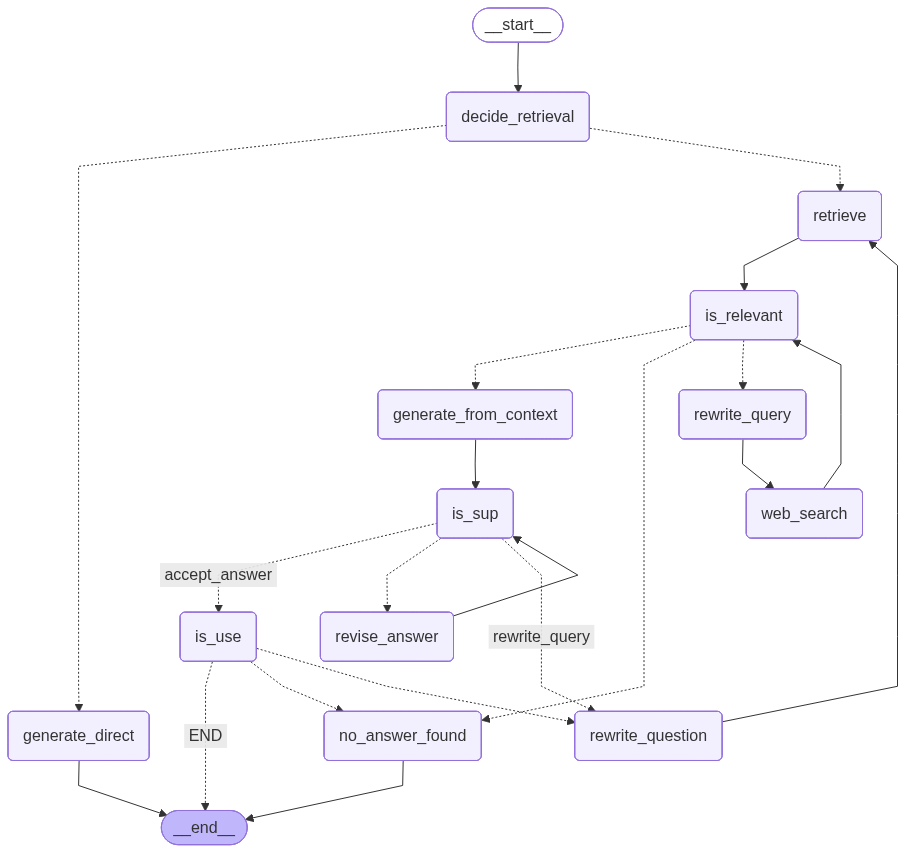

In [43]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

# IsSUP + revise loop
g.add_node("is_sup", is_sup)
g.add_node("revise_answer", revise_answer)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("rewrite_question",rewrite_question)

# ✅ NEW: IsUSE + finalize
g.add_node("is_use", is_use)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_answer_found": "no_answer_found",
        "rewrite_query": "rewrite_query",
    },
)

g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")  # loop back to relevance check after web search

# If no answer found, end
g.add_edge("no_answer_found", END)

# --------------------
# Generate -> IsSUP -> (IsUSE | revise) loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",      # ✅ fully_supported goes to IsUSE
        "revise_answer": "revise_answer",
        "rewrite_query": "rewrite_question",  # if support fails, reorder retrieval path
    },
)

# revise then re-check support
g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",  # Option to rewrite question if answer is not useful
        "no_answer_found": "no_answer_found",
    },
)

g.add_edge("rewrite_question", "retrieve")  

app = g.compile()
app

In [44]:
initial_state = {
    "question": "What is the current ai news of 2026",
    "retrieval_query": "Has Openai Made Any Advancement in 2026",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 200},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")

KeyboardInterrupt: 